# X-ray Analysis

Characterizing the x-ray (prompt) feature on its own: onset, rise time, fall time, FWHM.
Validated across all 12 verified double-pulse shots below; the logic now lives in
`shot_characterization/xray.py` (`find_xray_shape()`) -- this notebook just calls it.

**Onset**: find the peak (raw-signal threshold crossing, refined to local max), then walk
backward from it until the signal drops back within ~2 sigma of the pre-trigger baseline
noise.

**Rise time**: 10%/90%-of-peak-height crossings, searched only between the onset and the
peak -- not a fixed window. A fixed window was tried first and produced nonsense (~4-5 ns
"rise times" on several shots, right at the window boundary) because these traces have small
noise/ringing excursions *before* the real pulse starts, and a wide window can catch one of
those instead of the true rising edge. Bounding the search to [onset, peak] uses the onset
detection (which is already validated) to rule that out.

**Fall time, FWHM**: same 10%/50%/90% idea on the falling side, using the *first* crossing
walking forward from the peak (not the last) -- these pulses ring/oscillate for several ns
after the peak too, so "last crossing in a window" picks up a random later ringing bump
instead of the true initial decay (found via shot 9, where it produced a fall time 25x too
large).


In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

import shot_log as sl
from helpers import load_channel
from shot_characterization.characterize import characterize
from shot_characterization import VERIFIED_CATEGORY, find_xray_shape


## Check on one shot

shot 9: onset=96.166ns  peak=96.487ns  rise=0.21093750000004263ns  fall=0.17187499999994316ns  fwhm=0.36718749999995737ns


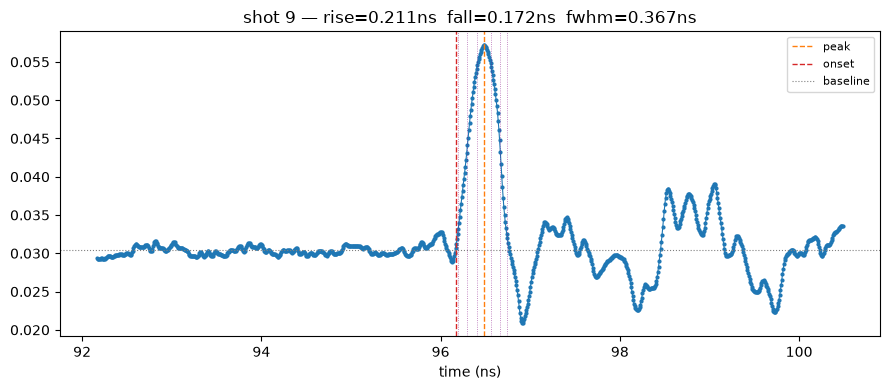

{'peak_time_ns': 96.48654452296677,
 'peak_val_V': 0.05718083858218419,
 'onset_time_ns': 96.16623202296681,
 'onset_val_V': 0.03064623252180332,
 'rise_time_ns': 0.21093750000004263,
 'fall_time_ns': 0.17187499999994316,
 'fwhm_ns': 0.36718749999995737,
 'edge_times_ns': {'r10_i': 96.19748202296677,
  'f10_i': 96.73654452296678,
  'r50_i': 96.29904452296678,
  'f50_i': 96.66623202296674,
  'r90_i': 96.40841952296681,
  'f90_i': 96.56466952296684}}

In [3]:
def plot_xray_shape(shot, pad_ns=4):
    entry = sl.main_channel_entry(shot)
    kind, path, ch = entry
    t, v, clipped, ydisp = load_channel(sl.DATA_DIR, kind, path, ch)
    res = characterize(t, v, clipped)
    baseline, noise = res["baseline_V"], res["noise_V"]

    xr = find_xray_shape(t, v, baseline, noise)
    if xr is None:
        print(f"shot {shot}: nothing found")
        return None
    print(f"shot {shot}: onset={xr['onset_time_ns']:.3f}ns  peak={xr['peak_time_ns']:.3f}ns  "
          f"rise={xr['rise_time_ns']}ns  fall={xr['fall_time_ns']}ns  fwhm={xr['fwhm_ns']}ns")

    t_ns = t * 1e9
    lo, hi = xr["onset_time_ns"] - pad_ns, xr["peak_time_ns"] + pad_ns
    mask = (t_ns >= lo) & (t_ns <= hi)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(t_ns[mask], v[mask], marker=".", ms=4, lw=0.8, zorder=1)
    ax.axvline(xr["peak_time_ns"], color="tab:orange", ls="--", lw=1, label="peak")
    ax.axvline(xr["onset_time_ns"], color="tab:red", ls="--", lw=1, label="onset")
    ax.axhline(baseline, color="gray", ls=":", lw=0.8, label="baseline")

    et = xr["edge_times_ns"]
    for key in ["r10_i", "r50_i", "r90_i", "f90_i", "f50_i", "f10_i"]:
        tt = et.get(key)
        if tt is not None:
            ax.axvline(tt, color="purple", ls=":", lw=0.6, alpha=0.6)

    ax.legend(fontsize=8)
    ax.set_title(f"shot {shot} — rise={xr['rise_time_ns']:.3f}ns  "
                 f"fall={xr['fall_time_ns']:.3f}ns  fwhm={xr['fwhm_ns']:.3f}ns")
    ax.set_xlabel("time (ns)")
    plt.tight_layout()
    plt.show()
    return xr

plot_xray_shape(9)


## Check on every verified double-pulse shot

12 verified double-pulse shots: [9, 11, 15, 16, 18, 19, 20, 21, 22, 25, 26, 27]
shot 9: onset=96.166ns  peak=96.487ns  rise=0.21093750000004263ns  fall=0.17187499999994316ns  fwhm=0.36718749999995737ns


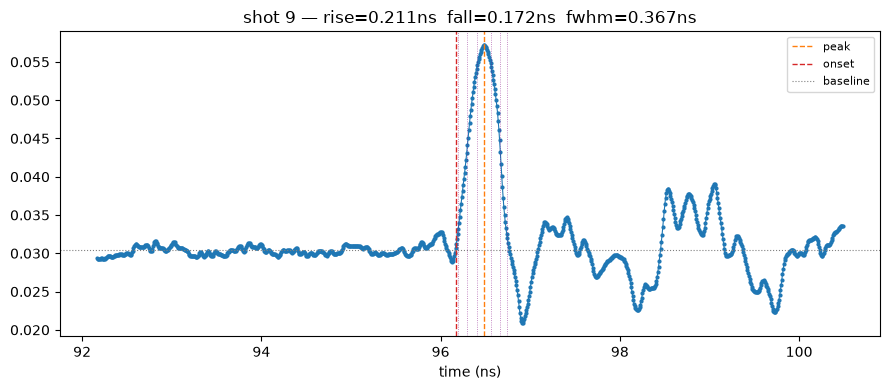

shot 11: onset=95.396ns  peak=96.396ns  rise=0.2500000000039364ns  fall=0.4999999999807585ns  fwhm=0.2500000000039364ns


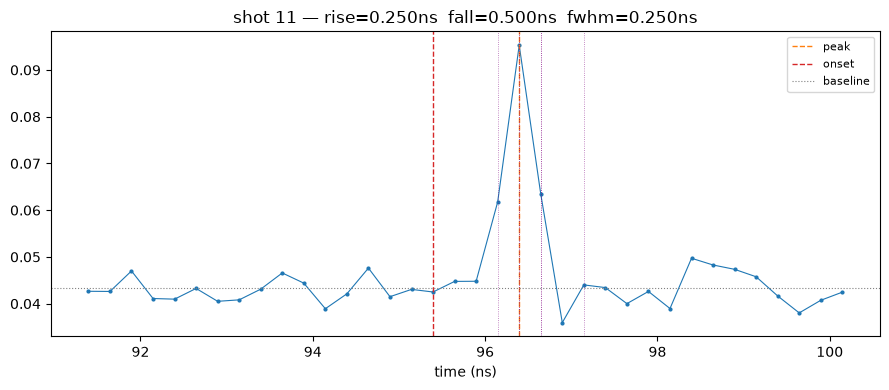

shot 15: onset=102.412ns  peak=102.795ns  rise=0.1874999999999858ns  fall=0.062499999999914735ns  fwhm=0.3749999999999858ns


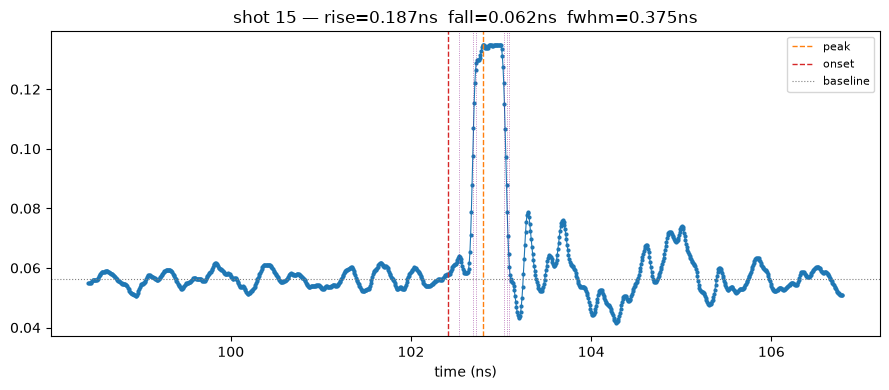

shot 16: onset=102.617ns  peak=102.836ns  rise=0.07812499999997158ns  fall=0.35937499999994316ns  fwhm=0.46093749999994316ns


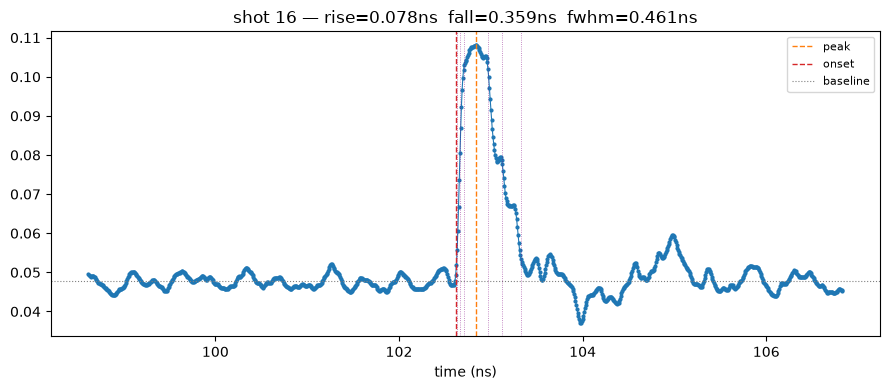

shot 18: onset=4.576ns  peak=4.873ns  rise=0.17968750000007638ns  fall=0.3203124999999609ns  fwhm=0.4687499999999689ns


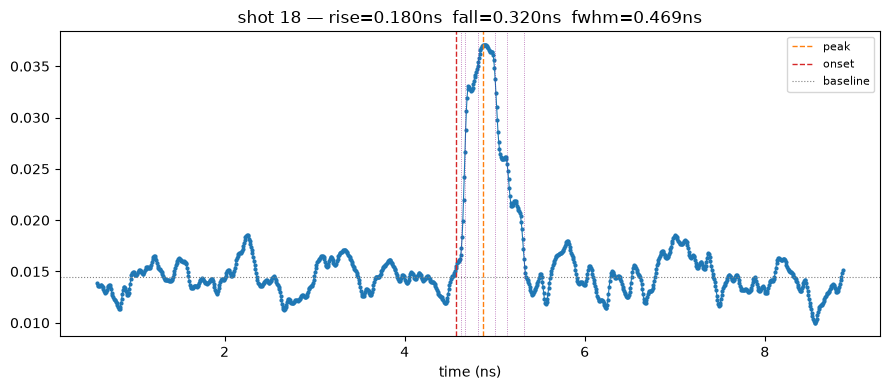

shot 19: onset=0.347ns  peak=0.565ns  rise=0.07812499999995959ns  fall=0.0546875000000141ns  fwhm=0.34375000000001255ns


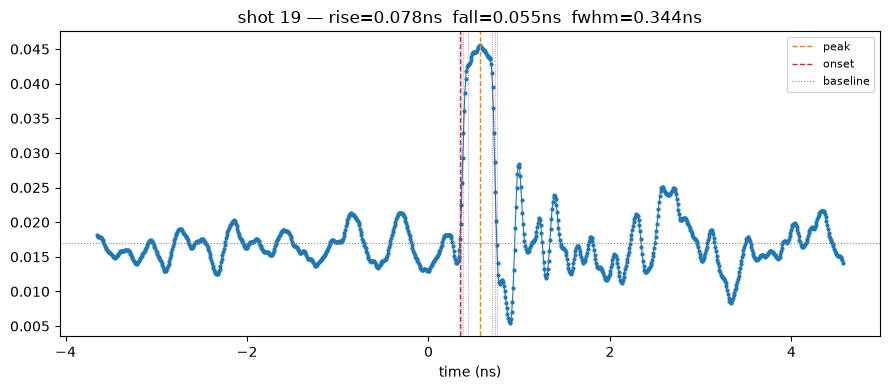

shot 20: onset=1.796ns  peak=2.061ns  rise=0.0703125000000484ns  fall=0.28906249999999867ns  fwhm=0.35156249999992384ns


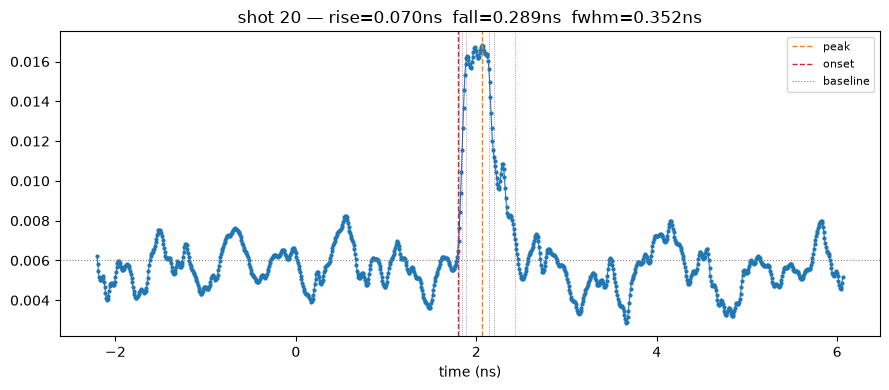

shot 21: onset=1.758ns  peak=2.219ns  rise=0.35156250000002953ns  fall=0.35156250000002975ns  fwhm=0.36718750000006395ns


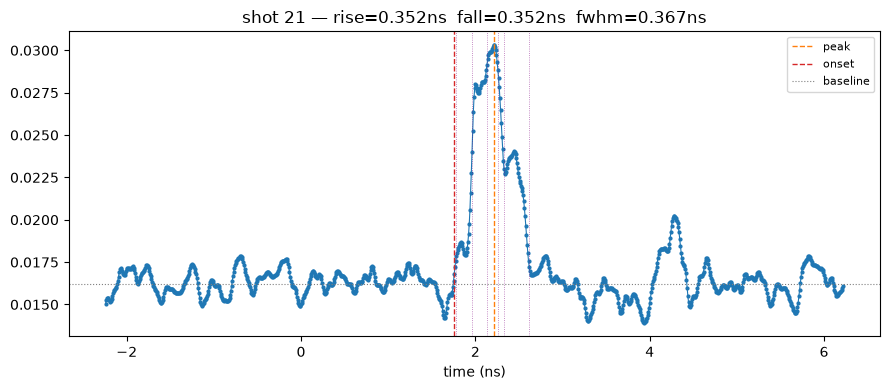

shot 22: onset=-1.112ns  peak=-0.596ns  rise=0.24218750000000178ns  fall=0.06249999999999145ns  fwhm=0.3593750000000072ns


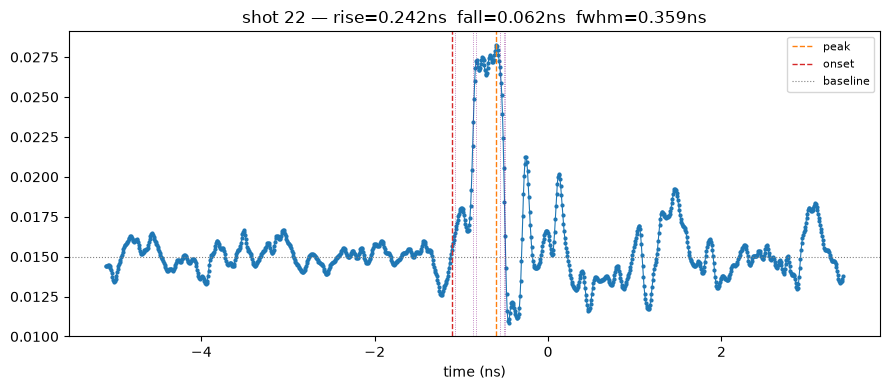

shot 25: onset=3.972ns  peak=4.269ns  rise=0.24218750000000178ns  fall=0.31249999999994404ns  fwhm=0.3593750000000471ns


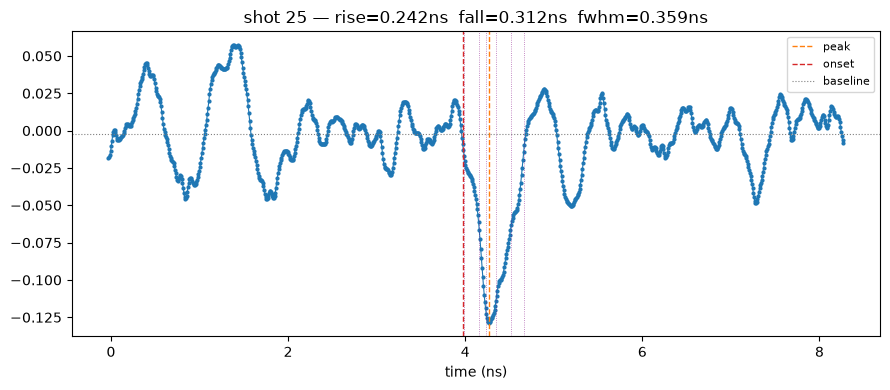

shot 26: onset=1.181ns  peak=1.767ns  rise=0.41406250000006084ns  fall=0.34374999999990696ns  fwhm=0.5312500000000004ns


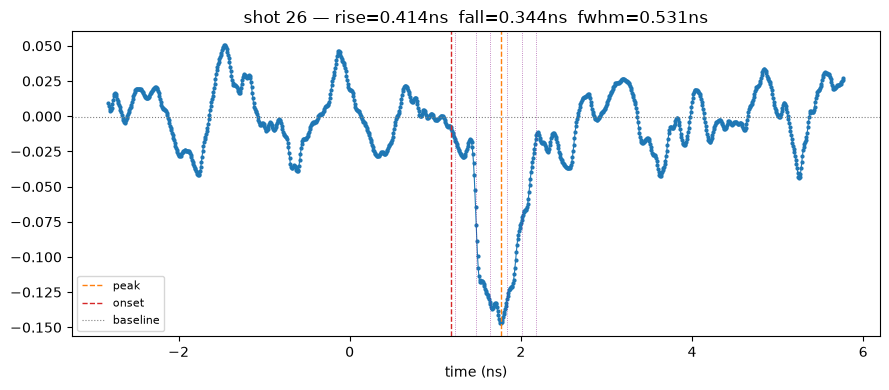

shot 27: onset=1.822ns  peak=2.009ns  rise=0.10156250000001088ns  fall=0.29687500000001554ns  fwhm=0.30468750000003286ns


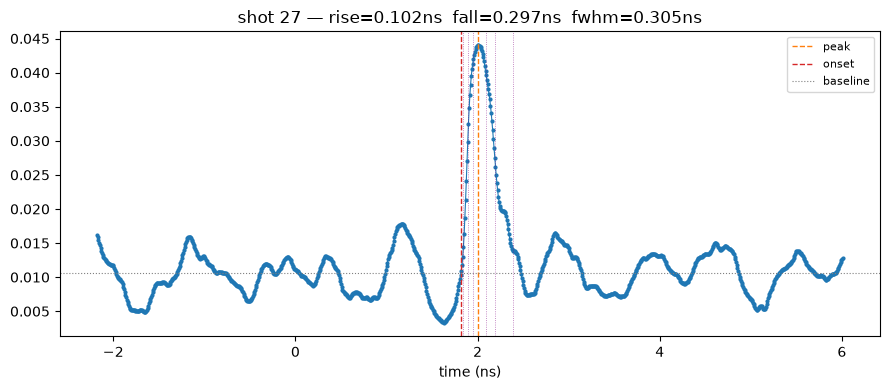

In [4]:
DOUBLE_PULSE_SHOTS = sorted(s for s, cat in VERIFIED_CATEGORY.items()
                            if cat == "Double pulse (prompt + delayed candidate)")
print(f"{len(DOUBLE_PULSE_SHOTS)} verified double-pulse shots:", DOUBLE_PULSE_SHOTS)

for shot in DOUBLE_PULSE_SHOTS:
    plot_xray_shape(shot)
